In [1]:
import os
import json
import yaml
import numpy as np
import matplotlib.pyplot as plt
def read_config(file_path):
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

def is_config_valid(config, ref_config, ignore_fields, enforce_existence=True):
    for key, value in ref_config.items():
        if enforce_existence and config.get(key) is None:
            return False
        if key not in ignore_fields and config.get(key) != value:
            print('captured unmatching field:', key)
            return False
    return True

def valid_directories(search_path, ref_config, config_ignore_fields):
    valid_dirs = []
    for directory in os.listdir(search_path):
        dir_path = os.path.join(search_path, directory)
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(config_path):
            config = read_config(config_path)
            print('evaluating config:', config_path)
            if (ref_config is None) or is_config_valid(config, ref_config, config_ignore_fields):
                valid_dirs.append(directory)
    return valid_dirs

def read_epochs_data(file_path):
    with open(file_path, 'r') as file:
        return [json.loads(line) for line in file]

def is_run_valid(epoch_data, min_epoch,require_finish_flag=True, finish_flag=None):
    if require_finish_flag:
        return len(epoch_data) >= min_epoch and os.path.isfile(finish_flag)
    else:
        return len(epoch_data) >= min_epoch

def aggregate_results(valid_dirs, min_epoch, search_path):
    all_results = {}
    all_configs ={}
    for dir_name in valid_dirs:
        dir_path = os.path.join(search_path, dir_name)
        results_path = os.path.join(dir_path, 'results', 'epoch_data.json')
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(results_path):
            epoch_data = read_epochs_data(results_path)
            if is_run_valid(epoch_data, 
                            min_epoch, 
                            require_finish_flag=True, 
                            finish_flag = os.path.join(dir_path,'run_finished')):
#             if  os.path.isfile(os.path.join(dir_path,'run_finished')):
                dir_results = {}
                for epoch in epoch_data:
                    for key, value in epoch.items():
                        if key not in dir_results:
                            dir_results[key] = []
                        dir_results[key].append(value)
                all_results[dir_name] = dir_results
                all_configs[dir_name] = read_config(config_path)
    return all_results, all_configs

# Main function
def analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch):
    ref_config = read_config(ref_config_path) if ref_config_path is not None else None
    valid_dirs = valid_directories(search_path, ref_config, config_ignore_fields)
    return aggregate_results(valid_dirs, min_epoch, search_path)

def mean_k_last_result(result_dicts,key,k_last, as_dict=False):
    results = {} if as_dict else []
    for run_name, result_dict in result_dicts.items():
        if key in result_dict.keys():
            this_result = np.mean(result_dict[key][-k_last:])
            if as_dict:
                results[run_name] = this_result
            else:
                results.append(this_result)
        else:
            print(f'warning, no such a field in run name:{run_name}')
    return results


In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def add_inset_with_symbols(ax, width="30%", height="30%", loc=1, 
                           styles=None, titles = None, 
                           bbox=(0.5, 0.5, 0.5, 0.5)):
    """
    Add an inset to the given axis with symbols and their meanings.

    Parameters:
    ax (matplotlib.axes.Axes): The axis to add the inset to.
    width (str): Width of the inset as a percentage of the parent axis.
    height (str): Height of the inset as a percentage of the parent axis.
    loc (int): Location code for the inset (1=upper right, 2=upper left, etc.).
    """
    # Define inset axis
    inset_ax = inset_axes(ax, width=width, height=height, bbox_to_anchor=bbox, loc=loc,
                         bbox_transform=ax.transAxes)

    # Add the symbols and their meanings to the inset

    for style, title in zip(styles, titles):
        inset_ax.plot([], [], style, label=title)

    # Hide the inset axis ticks and labels
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.legend(loc='center')

In [3]:
# epochs_data_with_aug = read_epochs_data('../saved_runs_old/horiz_ds_April7_19/results/epoch_data.json')

In [4]:
# epochs_data_without_aug = read_epochs_data('../saved_runs_old/horiz_ds_April7_20/results/epoch_data.json')

In [5]:
epochs_data_with_aug = read_epochs_data('../saved_runs/redoAugmentNoAugment_Augment_/results/epoch_data.json')
epochs_data_without_aug = read_epochs_data('../saved_runs/redoAugmentNoAugment_noAugment_/results/epoch_data.json')

In [6]:
def transpose_list_of_dicts(list_of_dicts):
    '''Turns a list of dictionaries into a dictionary of lists.
    
    Args:
        list_of_dicts (list): A list of dictionaries.

    Returns:
        dict: A dictionary where each key is from the original dictionaries and each value is a list of values from all dictionaries for that key.
    '''
    # Initialize an empty dictionary to store the transposed data
    transposed_dict = {}

    # Iterate over each dictionary in the list
    for d in list_of_dicts:
        for key, value in d.items():
            # Append the value to the correct list in the transposed dictionary
            if key in transposed_dict:
                transposed_dict[key].append(value)
            else:
                transposed_dict[key] = [value]

    return transposed_dict


In [7]:
measure_data_with_aug = transpose_list_of_dicts(epochs_data_with_aug)
measure_data_without_aug = transpose_list_of_dicts(epochs_data_without_aug)

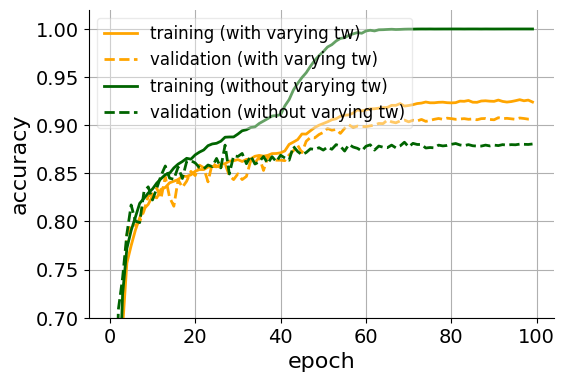

In [8]:
import matplotlib.pyplot as plt

# Create a figure of size 15x10
# plt.figure(figsize=(15, 10))
plt.figure(1,figsize=(6,4))

plt.rcParams.update({'font.size': 14})
ax = plt.gca()
# Define colors and markers
colors = {'with_aug': 'orange', 'without_aug': 'darkgreen'}
markers = {'val': 's', 'train': '^'}
markersize = 5
linewidth = 2

# Plot validation accuracy and training accuracy with varying time window
plt.plot(measure_data_with_aug['epoch'], measure_data_with_aug['train_acc'], 
         label='training (with varying tw)', color=colors['with_aug'], #marker=markers['train'], 
         linewidth=linewidth, markersize=markersize)
plt.plot(measure_data_with_aug['epoch'], measure_data_with_aug['val_acc'], 
         label='validation (with varying tw)', color=colors['with_aug'], #marker=markers['val'], 
         linewidth=linewidth, linestyle='--', markersize=markersize)


# Plot validation accuracy and training accuracy without varying time window
plt.plot(measure_data_without_aug['epoch'], measure_data_without_aug['train_acc'], 
         label='training (without varying tw)', color=colors['without_aug'], #marker=markers['train'], 
         linewidth=linewidth, markersize=markersize)
plt.plot(measure_data_without_aug['epoch'], measure_data_without_aug['val_acc'], 
         label='validation (without varying tw)', color=colors['without_aug'], #marker=markers['val'], 
         linewidth=linewidth, linestyle='--', markersize=markersize)


# Add title and labels
# plt.title('training and validation accuracy with and without varying time window', fontsize=20)
plt.xlabel('epoch', fontsize=16)
plt.ylabel('accuracy', fontsize=16)

# Add a legend
plt.legend(loc='upper left', fontsize=12, framealpha=0.4)
ax.spines[['right', 'top']].set_visible(False)

# Show grid
plt.grid(True)
plt.ylim([0.7, 1.02])

# Display the plot
plt.show()


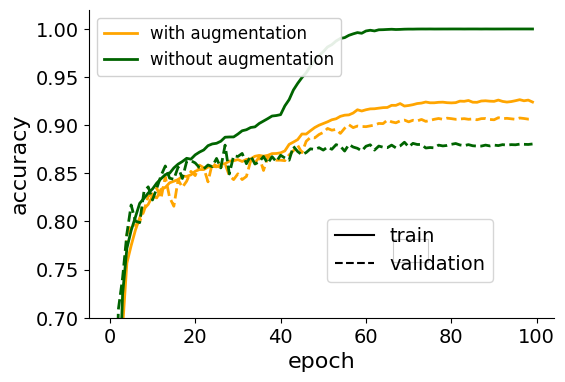

In [17]:
import matplotlib.pyplot as plt

# Create a figure of size 15x10
# plt.figure(figsize=(15, 10))
plt.figure(1,figsize=(6,4))

plt.rcParams.update({'font.size': 14})
ax = plt.gca()
# Define colors and markers
colors = {'with_aug': 'orange', 'without_aug': 'darkgreen'}
markers = {'val': 's', 'train': '^'}
markersize = 5
linewidth = 2

# Plot validation accuracy and training accuracy with varying time window
plt.plot(measure_data_with_aug['epoch'], measure_data_with_aug['train_acc'], 
         label='with augmentation', color=colors['with_aug'], #marker=markers['train'], 
         linewidth=linewidth, markersize=markersize)
plt.plot(measure_data_with_aug['epoch'], measure_data_with_aug['val_acc'], 
          color=colors['with_aug'], #marker=markers['val'], 
         linewidth=linewidth, linestyle='--', markersize=markersize)


# Plot validation accuracy and training accuracy without varying time window
plt.plot(measure_data_without_aug['epoch'], measure_data_without_aug['train_acc'], 
         label='without augmentation', color=colors['without_aug'], #marker=markers['train'], 
         linewidth=linewidth, markersize=markersize)
plt.plot(measure_data_without_aug['epoch'], measure_data_without_aug['val_acc'], 
         color=colors['without_aug'], #marker=markers['val'], 
         linewidth=linewidth, linestyle='--', markersize=markersize)


# Add title and labels
# plt.title('training and validation accuracy with and without varying time window', fontsize=20)
plt.xlabel('epoch', fontsize=16)
plt.ylabel('accuracy', fontsize=16)

# Add a legend
plt.legend(loc='upper left', fontsize=12, framealpha=0.9)
ax.spines[['right', 'top']].set_visible(False)

plt.grid(False)
plt.ylim([0.7, 1.02])

add_inset_with_symbols(ax, width="15%", height="15%", loc=4, styles=['k-','k--'], titles = ['train','validation'],
                       bbox=(0.25,0.15,0.5,0.5))

# Display the plot
plt.savefig('fig3panelB.svg',format='svg')
plt.show()


In [14]:
# # Keep only the columns used in the plots
# with_aug_export = measure_data_with_aug[['epoch', 'train_acc', 'val_acc']].copy()
# with_aug_export = with_aug_export.rename(columns={
#     'train_acc': 'train_acc_with_aug',
#     'val_acc': 'val_acc_with_aug'
# })

# without_aug_export = measure_data_without_aug[['epoch', 'train_acc', 'val_acc']].copy()
# without_aug_export = without_aug_export.rename(columns={
#     'train_acc': 'train_acc_without_aug',
#     'val_acc': 'val_acc_without_aug'
# })

# # Merge by epoch so each row contains all 4 plotted values
# plot_data_export = pd.merge(
#     with_aug_export,
#     without_aug_export,
#     on='epoch',
#     how='outer'
# ).sort_values('epoch')

# # Export to CSV
# plot_data_export.to_csv(f'fig3panelB.csv', index=False)

# plot_data_export.head()

import pandas as pd

# Convert dicts to DataFrames first
with_aug_df = pd.DataFrame(measure_data_with_aug)
without_aug_df = pd.DataFrame(measure_data_without_aug)

with_aug_export = with_aug_df[['epoch', 'train_acc', 'val_acc']].copy()
with_aug_export = with_aug_export.rename(columns={
    'train_acc': 'train_acc_with_aug',
    'val_acc': 'val_acc_with_aug'
})

without_aug_export = without_aug_df[['epoch', 'train_acc', 'val_acc']].copy()
without_aug_export = without_aug_export.rename(columns={
    'train_acc': 'train_acc_without_aug',
    'val_acc': 'val_acc_without_aug'
})

plot_data_export = pd.merge(
    with_aug_export,
    without_aug_export,
    on='epoch',
    how='outer'
).sort_values('epoch')

plot_data_export.to_csv(f'fig3panelB.csv', index=False)


In [15]:
plot_data_export

,epoch,train_acc_with_aug,val_acc_with_aug,train_acc_without_aug,val_acc_without_aug
0,0,0.107762,0.109500,0.130394,0.174833
1,1,0.138790,0.273500,0.333445,0.488667
2,2,0.451828,0.639167,0.598921,0.708333
3,3,0.689613,0.704500,0.724533,0.741500
4,4,0.756747,0.786333,0.772075,0.787167
...,...,...,...,...,...
95,95,0.925471,0.906167,1.000000,0.879667
96,96,0.926527,0.907500,1.000000,0.880333
97,97,0.925397,0.907000,1.000000,0.880167
98,98,0.926101,0.906333,1.000000,0.880000
